# SWE485 Project - Phase 1

# Medical Insurance Cost Risk and Advice System

## Group Information

| Student Name | Student ID | Responsibility |
|---|---:|---|
| Munthir Almukhif | 444101355 | Dataset loading and checking |
| Haitham Alduais | 444105932 | Summary and visualization |
| Mohammad Alfarraj | 443102025 | Preprocessing |


## Project Motivation

Medical insurance charges are different from one person to another. Age, BMI, smoking status, number of children, sex, and region may affect the final cost.

Our project uses this data to estimate medical insurance cost risk and give a simple cost-risk advice label: low, medium, or high.

## Problem Scope

The main target is `charges`, so the original task is regression. To make the project work as an advice system, we also create `risk_level` from the charges column.

The advice is only general cost-risk guidance. It is not medical advice.


## Dataset Goal and Source

Dataset name: Medical Cost Personal Dataset

Source: https://www.kaggle.com/datasets/mirichoi0218/insurance?resource=download

Goal: predict insurance charges using personal and health-related features.

## Columns

| Column | Type | Meaning |
|---|---|---|
| age | numeric | Age of the beneficiary |
| sex | categorical | male or female |
| bmi | numeric | Body Mass Index |
| children | numeric | Number of children/dependents |
| smoker | categorical | yes or no |
| region | categorical | US region |
| charges | numeric target | Medical insurance charges |


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("Dataset/insurance.csv")
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:

# Basic dataset information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset info:")
df.info()


Rows: 1338
Columns: 7

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## General Information

The dataset has 7 columns. There are 6 input features and 1 original target variable.

Original target: `charges`

`charges` is continuous, so this is mainly a regression problem.

For the advice part, we create a new column called `risk_level`:

- Low Cost Risk
- Medium Cost Risk
- High Cost Risk


In [3]:

# Statistical summary
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

summary = df[numeric_cols].agg(["count", "mean", "var", "std", "min", "median", "max"]).T
print("Numeric statistical summary:")
display(summary.round(3))

print("Categorical value counts:")
for col in categorical_cols:
    print("\n" + col)
    print(df[col].value_counts())


Numeric statistical summary:


,count,mean,var,std,min,median,max
age,1338.0,39.207,1.974010e+02,14.050,18.000,39.000,64.000
bmi,1338.0,30.663,3.718800e+01,6.098,15.960,30.400,53.130
children,1338.0,1.095,1.453000e+00,1.205,0.000,1.000,5.000
charges,1338.0,13270.422,1.466524e+08,12110.011,1121.874,9382.033,63770.428


Categorical value counts:

sex
sex
male      676
female    662
Name: count, dtype: int64

smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [4]:

# Missing values and duplicate rows
missing_values = df.isna().sum()
display(missing_values.to_frame("missing_values"))

print("Duplicate rows:", df.duplicated().sum())


,missing_values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Duplicate rows: 1


## Missing Values and Duplicates

We checked all columns for missing values. If the output shows zeros, then no imputation is needed.

We also checked duplicate rows. Duplicate rows are removed during preprocessing.


In [5]:

# Create the advice target
# The original target charges is numeric.
# For advice, we split charges into three cost-risk groups.

risk_names = ["Low Cost Risk", "Medium Cost Risk", "High Cost Risk"]

df["risk_level"] = pd.qcut(
    df["charges"],
    q=3,
    labels=risk_names
)

print("Risk level distribution:")
display(df["risk_level"].value_counts().reindex(risk_names).to_frame("count"))


Risk level distribution:


,count
risk_level,
Low Cost Risk,446
Medium Cost Risk,446
High Cost Risk,446


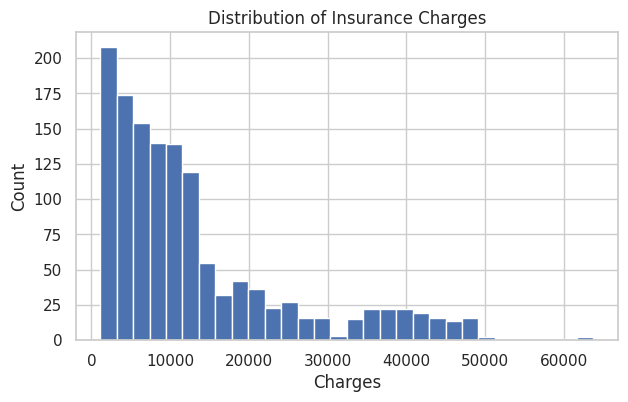

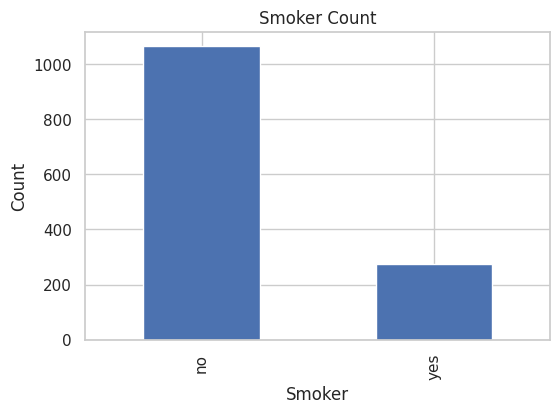

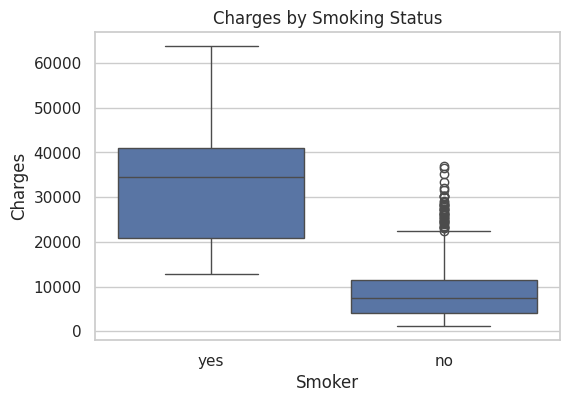

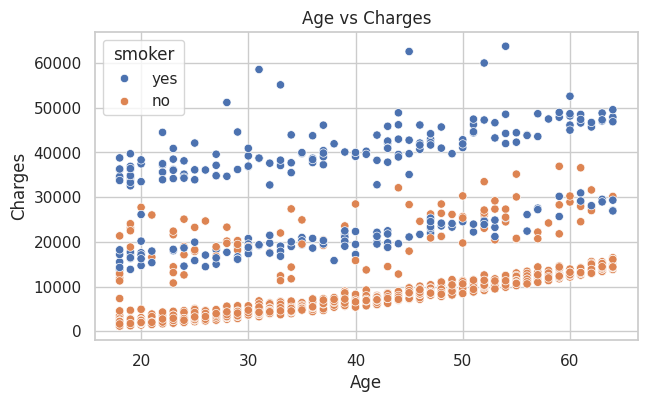

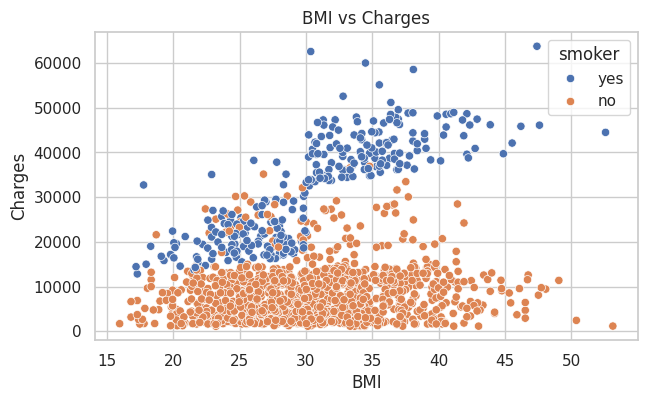

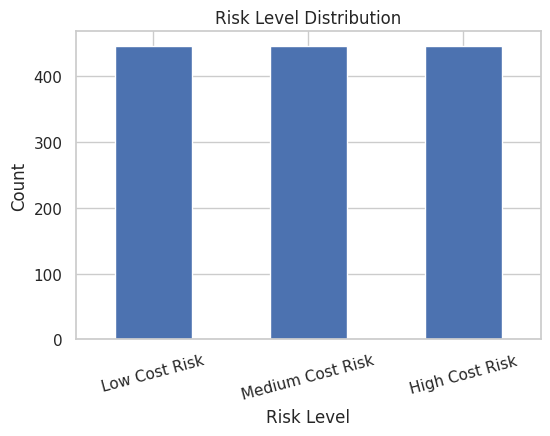

In [6]:
# Data visualization
plt.figure(figsize=(7, 4))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
df["smoker"].value_counts().plot(kind="bar")
plt.title("Smoker Count")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df)
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df)
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(6, 4))
df["risk_level"].value_counts().reindex(risk_names).plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

## Visualization Notes

From the plots, we can study the main relationships in the data.

The `charges` column is not evenly distributed. Some people have very high charges.

Smoking status is important because smokers usually have higher charges.

Age and BMI are also useful features because they may be related to insurance cost.

The risk level plot checks if the advice classes are balanced.


## Preprocessing Plan

The preprocessing steps are:

1. Remove duplicate rows if any exist.
2. Encode `sex` as 0 and 1.
3. Encode `smoker` as 0 and 1.
4. One-hot encode `region` because it has no natural order.
5. Standardize `age`, `bmi`, and `children` for scale-sensitive models.

We do not scale `charges` in Phase 1 because it is the prediction target.


In [7]:

# Preprocessing

df_clean = df.drop_duplicates().copy()

# Make sure risk_level exists after removing duplicates
df_clean["risk_level"] = pd.qcut(
    df_clean["charges"],
    q=3,
    labels=risk_names
)

# Binary encoding
df_clean["sex"] = df_clean["sex"].map({"female": 0, "male": 1})
df_clean["smoker"] = df_clean["smoker"].map({"no": 0, "yes": 1})

# One-hot encoding for region
df_model = pd.get_dummies(df_clean, columns=["region"], drop_first=True, dtype=int)

# Standardize selected numerical features only
scale_cols = ["age", "bmi", "children"]
df_scaled = df_model.copy()

for col in scale_cols:
    df_scaled[col] = (df_scaled[col] - df_scaled[col].mean()) / df_scaled[col].std()

print("Preprocessed data preview:")
display(df_model.head())

print("Scaled data preview:")
display(df_scaled.head())


Preprocessed data preview:


,age,sex,bmi,children,smoker,charges,risk_level,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,High Cost Risk,0,0,1
1,18,1,33.770,1,0,1725.55230,Low Cost Risk,0,1,0
2,28,1,33.000,3,0,4449.46200,Low Cost Risk,0,1,0
3,33,1,22.705,0,0,21984.47061,High Cost Risk,1,0,0
4,32,1,28.880,0,0,3866.85520,Low Cost Risk,1,0,0


Scaled data preview:


,age,sex,bmi,children,smoker,charges,risk_level,region_northwest,region_southeast,region_southwest
0,-1.439879,0,-0.452990,-0.908894,1,16884.92400,High Cost Risk,0,0,1
1,-1.511082,1,0.509231,-0.079412,0,1725.55230,Low Cost Risk,0,1,0
2,-0.799051,1,0.383011,1.579552,0,4449.46200,Low Cost Risk,0,1,0
3,-0.443036,1,-1.304564,-0.908894,0,21984.47061,High Cost Risk,1,0,0
4,-0.514239,1,-0.292347,-0.908894,0,3866.85520,Low Cost Risk,1,0,0


In [8]:
# Prepare features and targets for Phase 2
X = df_scaled.drop(columns=["charges", "risk_level"])
y_regression = df_scaled["charges"]
y_classification = df_scaled["risk_level"]

print("Feature matrix shape:", X.shape)
print("Regression target shape:", y_regression.shape)
print("Classification target shape:", y_classification.shape)

# Save the processed data
df_scaled.to_csv("Dataset/insurance_preprocessed_phase1.csv", index=False)
print("Saved: Dataset/insurance_preprocessed_phase1.csv")

Feature matrix shape: (1337, 8)
Regression target shape: (1337,)
Classification target shape: (1337,)
Saved: Dataset/insurance_preprocessed_phase1.csv


## Phase 1 Findings

The dataset was loaded successfully and contains numerical and categorical features.

There are no missing values in the dataset.

The target `charges` is continuous, so the main task is regression.

We created `risk_level` to make the system give simple advice labels.

Categorical values were converted to numbers so machine learning models can use them.

The cleaned data is now ready for Phase 2.
